In [1]:
from pathlib import Path
import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [2]:
root = Path('.')
boromir_2AFC_path = root / 'data' / 'boromir' / '2AFC'

In [3]:
filename = boromir_2AFC_path / 'session_011221a_condsAN.h5'
f = h5py.File(filename, 'r')
trials = list(f.keys())

In [4]:
# from all_trials_index_ORIG on the drive
n_trials_per_cond = {
    2: 7,
    3: 6,
    4: 6,
    5: 8,
    6: 8,
    7: 8
}

slice_idxs = np.cumsum(np.array(list(n_trials_per_cond.values())))
slice_idxs = np.insert(slice_idxs,0,0)

cond_keys_map = {}
cond_arr_map = {}

In [5]:
for key in n_trials_per_cond.keys():    
    slc = slice(slice_idxs[key-2],slice_idxs[key-1])
    cond_keys_map[key] = trials[slc]
    c = 0
    for trial in cond_keys_map[key]:
        dset = f[trial]
        arr = np.array(dset)
        arr = arr[:,:,np.newaxis]
        if c == 0:
            full_arr = arr.copy()
        else:
            full_arr = np.concatenate((full_arr, arr), axis=2)
        c += 1
    cond_arr_map[key] = full_arr

In [6]:
for key in cond_arr_map.keys():
    print(cond_arr_map[key].shape)

(10000, 256, 7)
(10000, 256, 6)
(10000, 256, 6)
(10000, 256, 8)
(10000, 256, 8)
(10000, 256, 8)


In [21]:
avg_arr = cond_arr_map[2].mean(axis=2)
arr_3d_avg = avg_arr.reshape((100,100,256))
print(avg_arr.shape)
print(arr_3d_avg.shape)

(10000, 256)
(100, 100, 256)


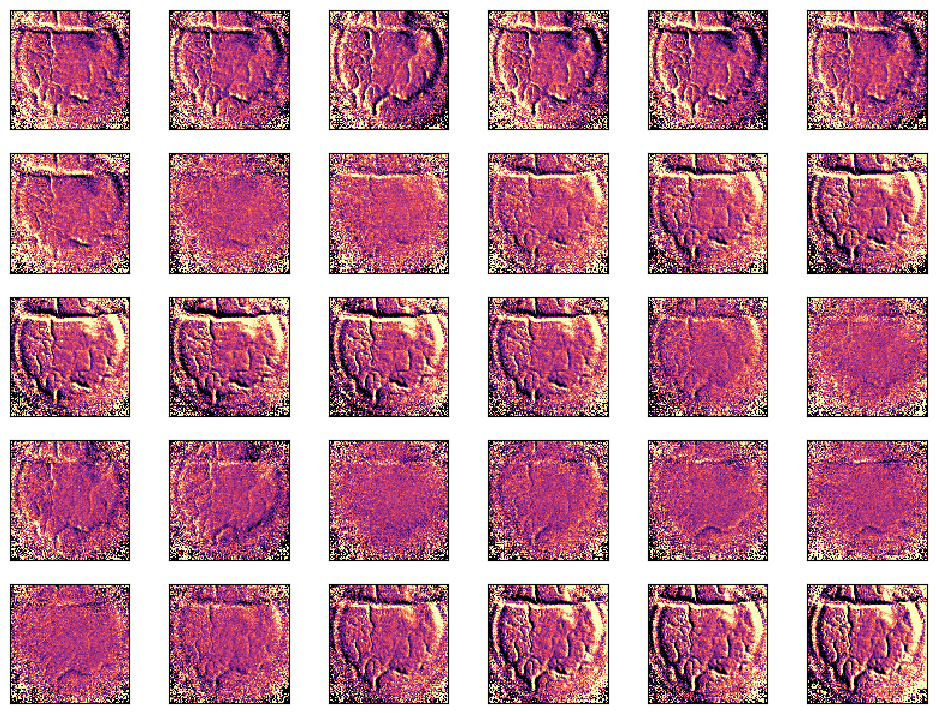

In [13]:
nrows, ncols = 5, 6
start_frame = 35
fig, axs = plt.subplots(ncols=ncols,nrows=nrows, figsize=(12,9))
frames = range(start_frame,start_frame+(nrows*ncols))

for ax, frame in zip(axs.flatten(), frames):
    ax.matshow(arr_3d_avg[:,:,frame], cmap='magma',vmin=1-0.001, vmax=1+0.001)
    ax.set_xticks([])
    ax.set_yticks([])

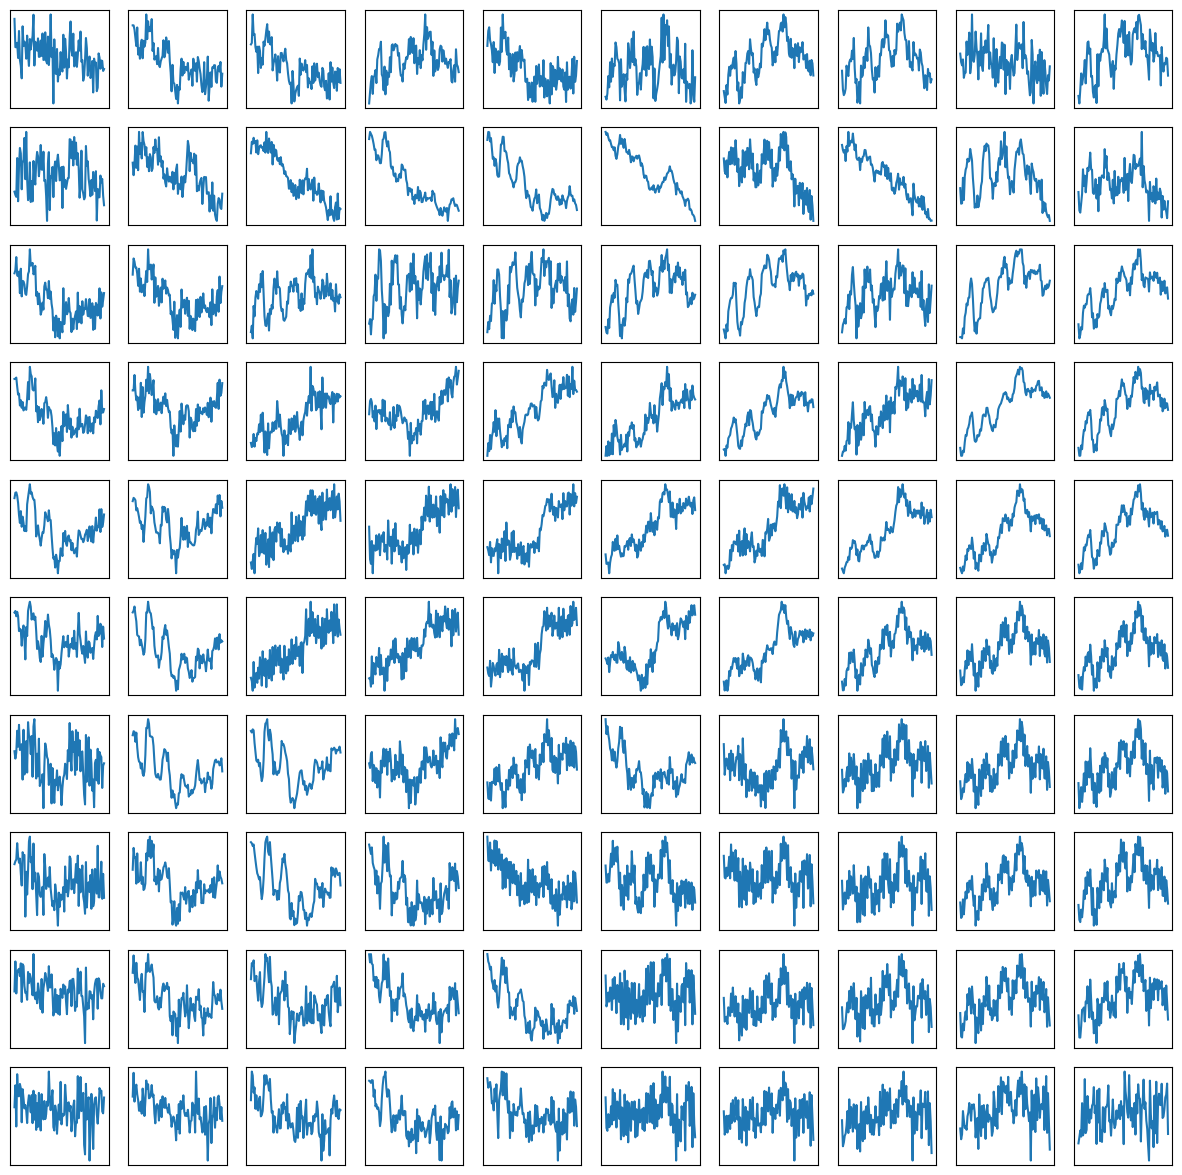

In [22]:
fig, axs = plt.subplots(ncols=10,nrows=10, figsize=(15,15))
frames = np.arange(20,120)
plots = []

for start_vertical in range(0,100,10):
    for start_horizontal in range(0,100,10):
        pix_10by10 = arr_3d_avg[start_vertical:start_vertical+10, start_horizontal:start_horizontal+10, 20:120]
        pix_10by10 = pix_10by10.mean(axis=0)
        pix_10by10 = pix_10by10.mean(axis=0)
        plots.append(pix_10by10)

for ax, plot in zip(axs.flatten(), plots):
    ax.plot(frames,plot)
    ax.set_xticks([])
    ax.set_yticks([])


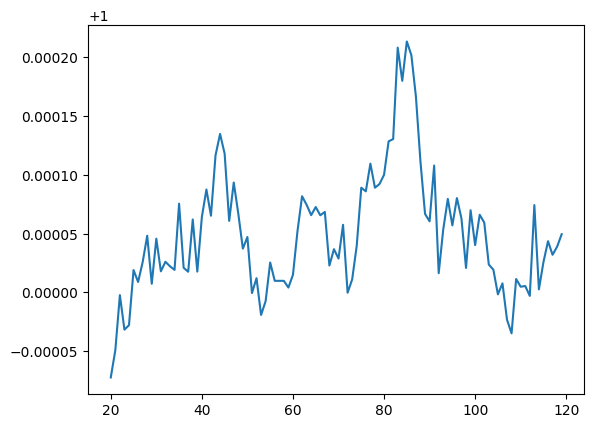

In [17]:
start_vertical = 40
start_horizontal = 50
pix_10by10 = arr_3d_avg[start_vertical:start_vertical+10, start_horizontal:start_horizontal+10, 20:120]
pix_10by10 = pix_10by10.mean(axis=0)
pix_10by10 = pix_10by10.mean(axis=0)
frames = np.arange(20,120)

plt.plot(frames,pix_10by10)
